# Predicción de comportamiento de compra en eCommerce con Big Data y PySpark

**Equipo 54**  
Salma Alejandra Macías Rosas — A01620186  
Marcelo Ismael López Verdugo — A00959089  
Dario Maximiliano Mendoza Orozco — A01361220  
Diana Jimena López Nájera — A01024913  

**Materia:** Análisis de grandes volúmenes de datos  
**Profesor:** Dr. Iván Olmos Pineda  
**Proyecto:** Comportamiento de usuarios en comercio electrónico  

## Contexto

El proyecto utiliza el dataset **eCommerce behavior data from multi category store**, específicamente el archivo de octubre de 2019. Cada registro representa un evento realizado por un usuario dentro de una tienda en línea multi-categoría, como visualizar un producto, agregarlo al carrito o comprarlo. El objetivo es analizar patrones de navegación y construir un modelo que permita predecir si un evento corresponde a una compra.

La población analizada contiene eventos de comportamiento a gran escala, por lo que el procesamiento se realiza con **PySpark**. Dado el fuerte desbalance natural del embudo de conversión —donde las visualizaciones son mucho más frecuentes que las compras— el flujo incorpora muestreo estratificado proporcional, validación cruzada k-fold y evaluación mediante F1-score ponderado.


!
!apt-get update -qq > /dev/null
!apt-get install openjdk-17-jdk-headless -qq > /dev/null
!wget -q https://dlcdn.apache.org/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz
!tar -xzf spark-3.5.8-bin-hadoop3.tgz
!pip install -q findspark

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.8-bin-hadoop3"

!ls

In [1]:
import findspark
findspark.init()
from pyspark import SparkContext, SparkConf, SQLContext
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True) # Property used to format output tables better
spark

from google.colab import drive
drive.mount('/content/drive')



import os
DIR = "/content/drive/MyDrive/Masters TEC/Materias/Big data /Big Data Notebooks"
os.chdir(DIR)

In [2]:
import os

# The DIR variable from a previous cell holds the path to the Google Drive folder.
# Using this to construct the absolute path to the CSV file.
DIR = '/content/drive/MyDrive/Masters TEC/Materias/Big data /Big Data Notebooks'
DIR="../datasets"
path = os.path.join(DIR, "2019-Oct.csv")

# Load data from file
df = spark.read.csv(path, header=True, inferSchema=True)


# Show first 3 rows
df.show(3)




+-------------------+----------+----------+-------------------+--------------------+--------+-----+---------+--------------------+
|         event_time|event_type|product_id|        category_id|       category_code|   brand|price|  user_id|        user_session|
+-------------------+----------+----------+-------------------+--------------------+--------+-----+---------+--------------------+
|2019-09-30 17:00:00|      view|  44600062|2103807459595387724|                NULL|shiseido|35.79|541312140|72d76fde-8bb3-4e0...|
|2019-09-30 17:00:00|      view|   3900821|2053013552326770905|appliances.enviro...|    aqua| 33.2|554748717|9333dfbd-b87a-470...|
|2019-09-30 17:00:01|      view|  17200506|2053013559792632471|furniture.living_...|    NULL|543.1|519107250|566511c2-e2e3-422...|
+-------------------+----------+----------+-------------------+--------------------+--------+-----+---------+--------------------+
only showing top 3 rows


In [3]:
df_raw = df

## 1. Preparación del entorno

Se inicializa una sesión de Spark configurada para procesamiento distribuido. Las librerías de PySpark se utilizan para carga, limpieza, transformación, muestreo y modelado. Pandas, Matplotlib y Seaborn se usan únicamente al final para visualizaciones sobre subconjuntos agregados o muestras controladas, evitando mover el dataset completo al driver.


In [4]:
# ============================================================
# 1. IMPORTACIONES Y CONFIGURACIÓN INICIAL
# ============================================================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType, StringType, TimestampType

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

SEED = 42
K_FOLDS = 3
SAMPLE_FRACTION = 0.10  # Ajustable según recursos del ambiente
MAX_BRANDS = 50         # Agrupación de marcas para controlar cardinalidad

spark = (
    SparkSession.builder
    .appName("Equipo54_Ecommerce_BigData_ML")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.driver.memory", "96g")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("SparkSession iniciada correctamente")


SparkSession iniciada correctamente


## 2. Carga de datos con PySpark

El dataset se encuentra en formato CSV y contiene eventos del mes de octubre de 2019. La ruta puede modificarse de acuerdo con el ambiente de ejecución: Google Colab, Databricks, ambiente local o clúster Spark.


## 3. Exploración inicial del dataset (EDA)

La exploración inicial valida volumen, estructura, tipos de datos, distribución de eventos, valores faltantes y estadísticas básicas de precio. Esta etapa es clave porque el dataset presenta un fuerte desbalance entre eventos de visualización, carrito y compra.


In [5]:
# ============================================================
# 3. EXPLORACIÓN INICIAL DEL DATASET
# ============================================================

# Vista inicial
print("Primeros registros:")
df_raw.show(5, truncate=False)

# Conteo de registros y columnas
n_rows = df_raw.count()
n_cols = len(df_raw.columns)
print(f"Dimensión del dataset: {n_rows:,} registros x {n_cols} columnas")

# Distribución de event_type
print("Distribución de event_type:")
(
    df_raw.groupBy("event_type")
    .count()
    .withColumn("porcentaje", F.round(F.col("count") / F.lit(n_rows) * 100, 4))
    .orderBy(F.desc("count"))
    .show(truncate=False)
)

# Valores faltantes por columna
missing_exprs = [
    F.sum(
        F.when(F.col(c).isNull() | (F.col(c).cast("string") == ""), 1).otherwise(0)
    ).alias(c)
    for c in df_raw.columns
]
print("Valores faltantes por columna:")
df_raw.select(missing_exprs).show(truncate=False)

# Estadística descriptiva de precio
print("Estadísticos de price:")
df_raw.select("price").describe().show()


Primeros registros:
+-------------------+----------+----------+-------------------+-----------------------------------+--------+-------+---------+------------------------------------+
|event_time         |event_type|product_id|category_id        |category_code                      |brand   |price  |user_id  |user_session                        |
+-------------------+----------+----------+-------------------+-----------------------------------+--------+-------+---------+------------------------------------+
|2019-09-30 17:00:00|view      |44600062  |2103807459595387724|NULL                               |shiseido|35.79  |541312140|72d76fde-8bb3-4e00-8c23-a032dfed738c|
|2019-09-30 17:00:00|view      |3900821   |2053013552326770905|appliances.environment.water_heater|aqua    |33.2   |554748717|9333dfbd-b87a-4708-9857-6336556b0fcc|
|2019-09-30 17:00:01|view      |17200506  |2053013559792632471|furniture.living_room.sofa         |NULL    |543.1  |519107250|566511c2-e2e3-422b-b695-cf8e6e792c

## 4. Limpieza de datos

La limpieza se realiza sin eliminar de forma masiva los registros con valores nulos en `category_code` y `brand`, porque esos faltantes representan una proporción relevante de la población. En su lugar, se asigna la etiqueta `unknown`, manteniendo la representatividad del dataset.

También se validan tipos de datos para asegurar que `event_time` sea timestamp y `price` sea numérico. Los registros con precio nulo o negativo se eliminan porque no son válidos para el análisis de rangos de precio ni para el modelo.


In [6]:
# ============================================================
# 4. LIMPIEZA DE DATOS Y VALIDACIÓN DE TIPOS
# ============================================================

required_cols = [
    "event_time", "event_type", "product_id", "category_id",
    "category_code", "brand", "price", "user_id", "user_session"
]

missing_required = [c for c in required_cols if c not in df_raw.columns]
if missing_required:
    raise ValueError(f"Faltan columnas requeridas: {missing_required}")

# Conversión explícita de tipos relevantes
df_clean = (
    df_raw
    .withColumn("event_time", F.to_timestamp("event_time"))
    .withColumn("price", F.col("price").cast(DoubleType()))
    .withColumn("event_type", F.col("event_type").cast(StringType()))
    .withColumn("category_code", F.col("category_code").cast(StringType()))
    .withColumn("brand", F.col("brand").cast(StringType()))
)

# Manejo de nulos en variables categóricas relevantes
df_clean = (
    df_clean
    .withColumn(
        "category_code_clean",
        F.when(F.col("category_code").isNull() | (F.trim(F.col("category_code")) == ""), F.lit("unknown"))
         .otherwise(F.col("category_code"))
    )
    .withColumn(
        "brand_clean",
        F.when(F.col("brand").isNull() | (F.trim(F.col("brand")) == ""), F.lit("unknown"))
         .otherwise(F.lower(F.col("brand")))
    )
)

# Reglas mínimas de calidad: timestamp válido, event_type válido y price no negativo
df_clean = (
    df_clean
    .filter(F.col("event_time").isNotNull())
    .filter(F.col("event_type").isin("view", "cart", "purchase"))
    .filter(F.col("price").isNotNull() & (F.col("price") >= 0))
)

print(f"Registros después de limpieza: {df_clean.count():,}")
df_clean.select("event_time", "event_type", "category_code_clean", "brand_clean", "price").show(5, truncate=False)


Registros después de limpieza: 42,448,764
+-------------------+----------+-----------------------------------+-----------+-------+
|event_time         |event_type|category_code_clean                |brand_clean|price  |
+-------------------+----------+-----------------------------------+-----------+-------+
|2019-09-30 17:00:00|view      |unknown                            |shiseido   |35.79  |
|2019-09-30 17:00:00|view      |appliances.environment.water_heater|aqua       |33.2   |
|2019-09-30 17:00:01|view      |furniture.living_room.sofa         |unknown    |543.1  |
|2019-09-30 17:00:01|view      |computers.notebook                 |lenovo     |251.74 |
|2019-09-30 17:00:04|view      |electronics.smartphone             |apple      |1081.98|
+-------------------+----------+-----------------------------------+-----------+-------+
only showing top 5 rows


## 5. Feature engineering

Se construyen variables derivadas coherentes con el particionamiento del proyecto:

- `weekhour`: combinación de día de la semana y hora para capturar patrón temporal semanal.
- `category_group`: categoría principal antes del primer punto en `category_code`.
- `price_range`: rango de precio (`low`, `medium`, `high`) usando los percentiles documentados en la caracterización: P25 = 64.78 y P75 = 357.77.
- `time_period`: periodo del día (`night`, `morning`, `afternoon`, `evening`) a partir de la hora del evento.
- `brand_grouped`: agrupación de marcas frecuentes y etiqueta `other` para controlar alta cardinalidad.


In [7]:
# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================

# Percentiles documentados en la caracterización del dataset
P25_PRICE = 64.78
P75_PRICE = 357.77

# Variables temporales y de particionamiento
df_fe = (
    df_clean
    .withColumn("hour", F.hour("event_time"))
    .withColumn("day_of_week", F.dayofweek("event_time"))
    .withColumn("weekhour", F.col("day_of_week") + F.col("hour") / F.lit(24.0))
    .withColumn("category_group", F.split(F.col("category_code_clean"), "\\.").getItem(0))
    .withColumn(
        "price_range",
        F.when(F.col("price") <= F.lit(P25_PRICE), F.lit("low"))
         .when(F.col("price") <= F.lit(P75_PRICE), F.lit("medium"))
         .otherwise(F.lit("high"))
    )
    .withColumn(
        "time_period",
        F.when((F.col("hour") >= 0) & (F.col("hour") < 6), F.lit("night"))
         .when((F.col("hour") >= 6) & (F.col("hour") < 12), F.lit("morning"))
         .when((F.col("hour") >= 12) & (F.col("hour") < 18), F.lit("afternoon"))
         .otherwise(F.lit("evening"))
    )
)

# Agrupación de marcas para controlar cardinalidad en el pipeline ML
top_brands = [
    r["brand_clean"]
    for r in (
        df_fe.groupBy("brand_clean")
        .count()
        .orderBy(F.desc("count"))
        .limit(MAX_BRANDS)
        .collect()
    )
]

df_fe = df_fe.withColumn(
    "brand_grouped",
    F.when(F.col("brand_clean").isin(top_brands), F.col("brand_clean")).otherwise(F.lit("other"))
)

# Validación rápida de variables derivadas
df_fe.select(
    "event_type", "category_code_clean", "category_group", "brand_grouped",
    "price", "price_range", "hour", "time_period", "weekhour"
).show(10, truncate=False)


+----------+-----------------------------------+--------------+-------------+-------+-----------+----+-----------+------------------+
|event_type|category_code_clean                |category_group|brand_grouped|price  |price_range|hour|time_period|weekhour          |
+----------+-----------------------------------+--------------+-------------+-------+-----------+----+-----------+------------------+
|view      |unknown                            |unknown       |other        |35.79  |low        |17  |afternoon  |2.7083333333333335|
|view      |appliances.environment.water_heater|appliances    |other        |33.2   |low        |17  |afternoon  |2.7083333333333335|
|view      |furniture.living_room.sofa         |furniture     |unknown      |543.1  |high       |17  |afternoon  |2.7083333333333335|
|view      |computers.notebook                 |computers     |lenovo       |251.74 |medium     |17  |afternoon  |2.7083333333333335|
|view      |electronics.smartphone             |electronics   

## 6. Construcción de muestra representativa

La muestra se construye mediante **muestreo estratificado proporcional**. Cada estrato se define por la combinación:

`event_type + category_group + price_range + time_period`

Esta regla conserva la estructura poblacional observada en el proyecto: acción del usuario, categoría general del producto, nivel de precio y periodo del día. Al aplicar la misma fracción de muestreo por estrato, se mantiene la proporción original de cada combinación dentro de la muestra.


In [ ]:
# ============================================================
# 6. MUESTREO ESTRATIFICADO PROPORCIONAL
# ============================================================

strata_cols = ["event_type", "category_group", "price_range", "time_period"]

# Crear identificador de estrato
df_strata = df_fe.withColumn("stratum", F.concat_ws("__", *[F.col(c) for c in strata_cols]))

# Calcular distribución poblacional por estrato para auditoría
strata_distribution = (
    df_strata.groupBy(strata_cols + ["stratum"])
    .count()
    .withColumn("population_share", F.col("count") / F.lit(df_strata.count()))
)

print("Principales estratos en la población:")
strata_distribution.orderBy(F.desc("count")).show(15, truncate=False)

# sampleBy requiere un diccionario {estrato: fracción}
strata_values = [r["stratum"] for r in df_strata.select("stratum").distinct().collect()]
fractions = {s: SAMPLE_FRACTION for s in strata_values}

M = (
    df_strata
    .sampleBy("stratum", fractions=fractions, seed=SEED)
    .cache()
)

m_count = M.count()
print(f"Tamaño de la muestra M: {m_count:,} registros")

print("Distribución de event_type en la muestra:")
(
    M.groupBy("event_type")
    .count()
    .withColumn("sample_share", F.round(F.col("count") / F.lit(m_count) * 100, 4))
    .orderBy(F.desc("count"))
    .show(truncate=False)
)


Principales estratos en la población:
+----------+--------------+-----------+-----------+----------------------------------+-------+--------------------+
|event_type|category_group|price_range|time_period|stratum                           |count  |population_share    |
+----------+--------------+-----------+-----------+----------------------------------+-------+--------------------+
|view      |electronics   |medium     |morning    |view__electronics__medium__morning|3026270|0.07129229958262154 |
|view      |electronics   |medium     |night      |view__electronics__medium__night  |2578533|0.06074459553168615 |
|view      |unknown       |medium     |morning    |view__unknown__medium__morning    |2226350|0.052447934644221914|
|view      |electronics   |high       |morning    |view__electronics__high__morning  |2212422|0.052119821439323887|
|view      |unknown       |low        |morning    |view__unknown__low__morning       |2099047|0.04944895450901703 |
|view      |electronics   |high   

## 7. Definición de variable objetivo

Se define la variable binaria `compro`:

- `compro = 1` si `event_type = purchase`
- `compro = 0` si `event_type` es `view` o `cart`

Importante: después de crear la etiqueta, `event_type` no se utiliza como variable predictora para evitar fuga de información, ya que define directamente la clase objetivo.


In [ ]:
# ============================================================
# 7. VARIABLE OBJETIVO
# ============================================================

M = M.withColumn("compro", F.when(F.col("event_type") == "purchase", F.lit(1.0)).otherwise(F.lit(0.0)))

print("Distribución de la variable objetivo compro:")
(
    M.groupBy("compro")
    .count()
    .withColumn("porcentaje", F.round(F.col("count") / F.lit(M.count()) * 100, 4))
    .orderBy("compro")
    .show()
)


Distribución de la variable objetivo compro:
+------+-------+----------+
|compro|  count|porcentaje|
+------+-------+----------+
|   0.0|4173037|   98.2627|
|   1.0|  73778|    1.7373|
+------+-------+----------+



## 8. División de datos mediante k-fold

Se utiliza validación cruzada manual con `k = 3`. Esta decisión equilibra robustez y costo computacional: con Big Data, usar valores mayores de k incrementa significativamente el tiempo de entrenamiento y las operaciones de shuffle. Con tres folds, cada iteración usa aproximadamente dos terceras partes de la muestra para entrenamiento y una tercera parte para validación.


In [ ]:
# ============================================================
# 8. CREACIÓN DE FOLDS
# ============================================================

M_folds = M.withColumn("fold", (F.rand(seed=SEED) * F.lit(K_FOLDS)).cast(IntegerType()))

print("Distribución de registros por fold:")
(
    M_folds.groupBy("fold")
    .count()
    .withColumn("porcentaje", F.round(F.col("count") / F.lit(M_folds.count()) * 100, 4))
    .orderBy("fold")
    .show()
)

print("Distribución de compro por fold:")
(
    M_folds.groupBy("fold", "compro")
    .count()
    .orderBy("fold", "compro")
    .show()
)


Distribución de registros por fold:
+----+-------+----------+
|fold|  count|porcentaje|
+----+-------+----------+
|   0|1416140|   33.3459|
|   1|1414257|   33.3016|
|   2|1416418|   33.3525|
+----+-------+----------+

Distribución de compro por fold:
+----+------+-------+
|fold|compro|  count|
+----+------+-------+
|   0|   0.0|1391638|
|   0|   1.0|  24502|
|   1|   0.0|1389630|
|   1|   1.0|  24627|
|   2|   0.0|1391769|
|   2|   1.0|  24649|
+----+------+-------+



## 9. Pipeline de Machine Learning

El pipeline utiliza:

1. `StringIndexer` para convertir categorías en índices numéricos.
2. `OneHotEncoder` para representar categorías sin imponer ordinalidad.
3. `VectorAssembler` para integrar variables categóricas codificadas y variables numéricas.
4. `DecisionTreeClassifier` como modelo interpretable para clasificación binaria.

El Árbol de Decisión es apropiado como modelo base porque permite capturar relaciones no lineales, interacciones simples entre variables y reglas interpretables para negocio.


In [ ]:
# ============================================================
# 9. DEFINICIÓN DEL PIPELINE DE MACHINE LEARNING
# ============================================================

categorical_features = ["category_group", "price_range", "time_period", "brand_grouped"]
numeric_features = ["price", "weekhour"]

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_features
]

encoders = [
    OneHotEncoder(
        inputCols=[f"{c}_idx" for c in categorical_features],
        outputCols=[f"{c}_vec" for c in categorical_features],
        handleInvalid="keep"
    )
]

assembler = VectorAssembler(
    inputCols=[f"{c}_vec" for c in categorical_features] + numeric_features,
    outputCol="features",
    handleInvalid="keep"
)

dt = DecisionTreeClassifier(
    labelCol="compro",
    featuresCol="features",
    maxDepth=5,
    minInstancesPerNode=20,
    seed=SEED
)

pipeline = Pipeline(stages=indexers + encoders + [assembler, dt])

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="compro",
    predictionCol="prediction",
    metricName="f1"
)

evaluator_accuracy = MulticlassClassificationEvaluator(
    labelCol="compro",
    predictionCol="prediction",
    metricName="accuracy"
)


## 10. Entrenamiento, evaluación y validación cruzada

En cada fold se entrena el pipeline con dos tercios de la muestra y se valida con el tercio restante. Se calcula F1-score ponderado tanto en entrenamiento como en validación para observar desempeño y detectar posible sobreajuste.


In [ ]:
resultados_cv = []
models = []

for i in range(K_FOLDS):
    print(f"\n================ Fold {i + 1}/{K_FOLDS} ================")
    start_time = time.time()

    # The `java.lang.OutOfMemoryError: Java heap space` persists during evaluation
    # (e.g., `f1_train = evaluator_f1.evaluate(pred_train)`).
    # This indicates that the Spark driver still lacks sufficient memory to process
    # the necessary data for model evaluation, even after increasing `spark.driver.memory`
    # to 8g and removing `.cache()` calls.
    # The most effective next step to resolve this persistent memory error is to:
    # 1. **Reduce the `SAMPLE_FRACTION`** value (currently 0.10) in cell `ZK9uZydUb_kq`
    #    to work with a smaller dataset, thus reducing the memory footprint for the driver.
    # 2. After changing `SAMPLE_FRACTION`, **restart the Colab runtime** and re-execute
    #    all cells to apply the new configuration.
    # There is no direct code fix within this specific cell that can address a
    # driver-level OutOfMemoryError, as it's a configuration/data size issue.

    # Removed .cache() to prevent OutOfMemoryError. This might lead to slower execution.
    train_df = M_folds.filter(F.col("fold") != i)
    val_df = M_folds.filter(F.col("fold") == i)

    train_count = train_df.count()
    val_count = val_df.count()
    print(f"Train: {train_count:,} registros | Validation: {val_count:,} registros")

    model = pipeline.fit(train_df)
    models.append(model)

    pred_train = model.transform(train_df)
    pred_val = model.transform(val_df)

    f1_train = evaluator_f1.evaluate(pred_train)
    f1_val = evaluator_f1.evaluate(pred_val)
    acc_train = evaluator_accuracy.evaluate(pred_train)
    acc_val = evaluator_accuracy.evaluate(pred_val)

    elapsed = time.time() - start_time

    resultados_cv.append({
        "Fold": i + 1,
        "Train_Count": train_count,
        "Validation_Count": val_count,
        "F1_Train": f1_train,
        "F1_Validation": f1_val,
        "Accuracy_Train": acc_train,
        "Accuracy_Validation": acc_val,
        "Tiempo_segundos": elapsed
    })

    print(f"F1 Train: {f1_train:.4f} | F1 Validation: {f1_val:.4f}")
    print(f"Accuracy Train: {acc_train:.4f} | Accuracy Validation: {acc_val:.4f}")
    print(f"Tiempo: {elapsed:.2f} segundos")

    # Unpersist calls are no longer necessary as .cache() was removed
    # train_df.unpersist()
    # val_df.unpersist()

resultados_pdf = pd.DataFrame(resultados_cv)
resultados_pdf


================ Fold 1/3 ================
Train: 2,830,675 registros | Validation: 1,416,140 registros
F1 Train: 0.9740 | F1 Validation: 0.9741
Accuracy Train: 0.9826 | Accuracy Validation: 0.9827
Tiempo: 9.10 segundos

================ Fold 2/3 ================
Train: 2,832,558 registros | Validation: 1,414,257 registros
F1 Train: 0.9740 | F1 Validation: 0.9740
Accuracy Train: 0.9826 | Accuracy Validation: 0.9826
Tiempo: 6.72 segundos

================ Fold 3/3 ================
Train: 2,830,397 registros | Validation: 1,416,418 registros
F1 Train: 0.9740 | F1 Validation: 0.9740
Accuracy Train: 0.9826 | Accuracy Validation: 0.9826
Tiempo: 6.49 segundos


,Fold,Train_Count,Validation_Count,F1_Train,F1_Validation,Accuracy_Train,Accuracy_Validation,Tiempo_segundos
0,1,2830675,1416140,0.973965,0.974123,0.982592,0.982698,9.095033
1,2,2832558,1414257,0.974048,0.973956,0.982648,0.982587,6.721834
2,3,2830397,1416418,0.974040,0.973973,0.982642,0.982598,6.492088


## 11. Justificación del F1-score ponderado

El dataset está desbalanceado porque la mayor parte de los eventos son visualizaciones y solo una proporción pequeña corresponde a compras. En este contexto, la exactitud puede ser engañosa: un modelo que prediga casi todo como “no compra” podría obtener alta accuracy, pero sería poco útil para identificar conversiones.

El **F1-score ponderado** combina precisión y recall por clase, ponderando cada clase de acuerdo con su soporte. Por ello, ofrece una lectura más adecuada del desempeño global en un problema de conversión desbalanceado.


In [ ]:
# ============================================================
# 11. RESUMEN DE MÉTRICAS
# ============================================================

print("Resultados por fold:")
print(resultados_pdf)

print("\nEstadísticos de validación:")
print(resultados_pdf[["F1_Validation", "Accuracy_Validation"]].describe())

f1_mean = resultados_pdf["F1_Validation"].mean()
f1_std = resultados_pdf["F1_Validation"].std()
print(f"\nF1-score promedio de validación: {f1_mean:.4f}")
print(f"Desviación estándar del F1-score de validación: {f1_std:.4f}")


Resultados por fold:
   Fold  Train_Count  Validation_Count  F1_Train  F1_Validation  \
0     1      2830675           1416140  0.973965       0.974123   
1     2      2832558           1414257  0.974048       0.973956   
2     3      2830397           1416418  0.974040       0.973973   

   Accuracy_Train  Accuracy_Validation  Tiempo_segundos  
0        0.982592             0.982698         9.095033  
1        0.982648             0.982587         6.721834  
2        0.982642             0.982598         6.492088  

Estadísticos de validación:
       F1_Validation  Accuracy_Validation
count       3.000000             3.000000
mean        0.974017             0.982627
std         0.000092             0.000061
min         0.973956             0.982587
25%         0.973965             0.982592
50%         0.973973             0.982598
75%         0.974048             0.982648
max         0.974123             0.982698

F1-score promedio de validación: 0.9740
Desviación estándar del F1-sco

## 12. Visualizaciones

Las visualizaciones permiten validar la estabilidad de los folds y revisar el comportamiento del modelo:

1. Histogramas de `price` por fold y clase objetivo.
2. Comparación de F1-score de entrenamiento vs validación.
3. Boxplot de variabilidad del F1-score de validación.

Para evitar saturar memoria, solo se convierte a Pandas una muestra controlada de columnas necesarias para graficar.


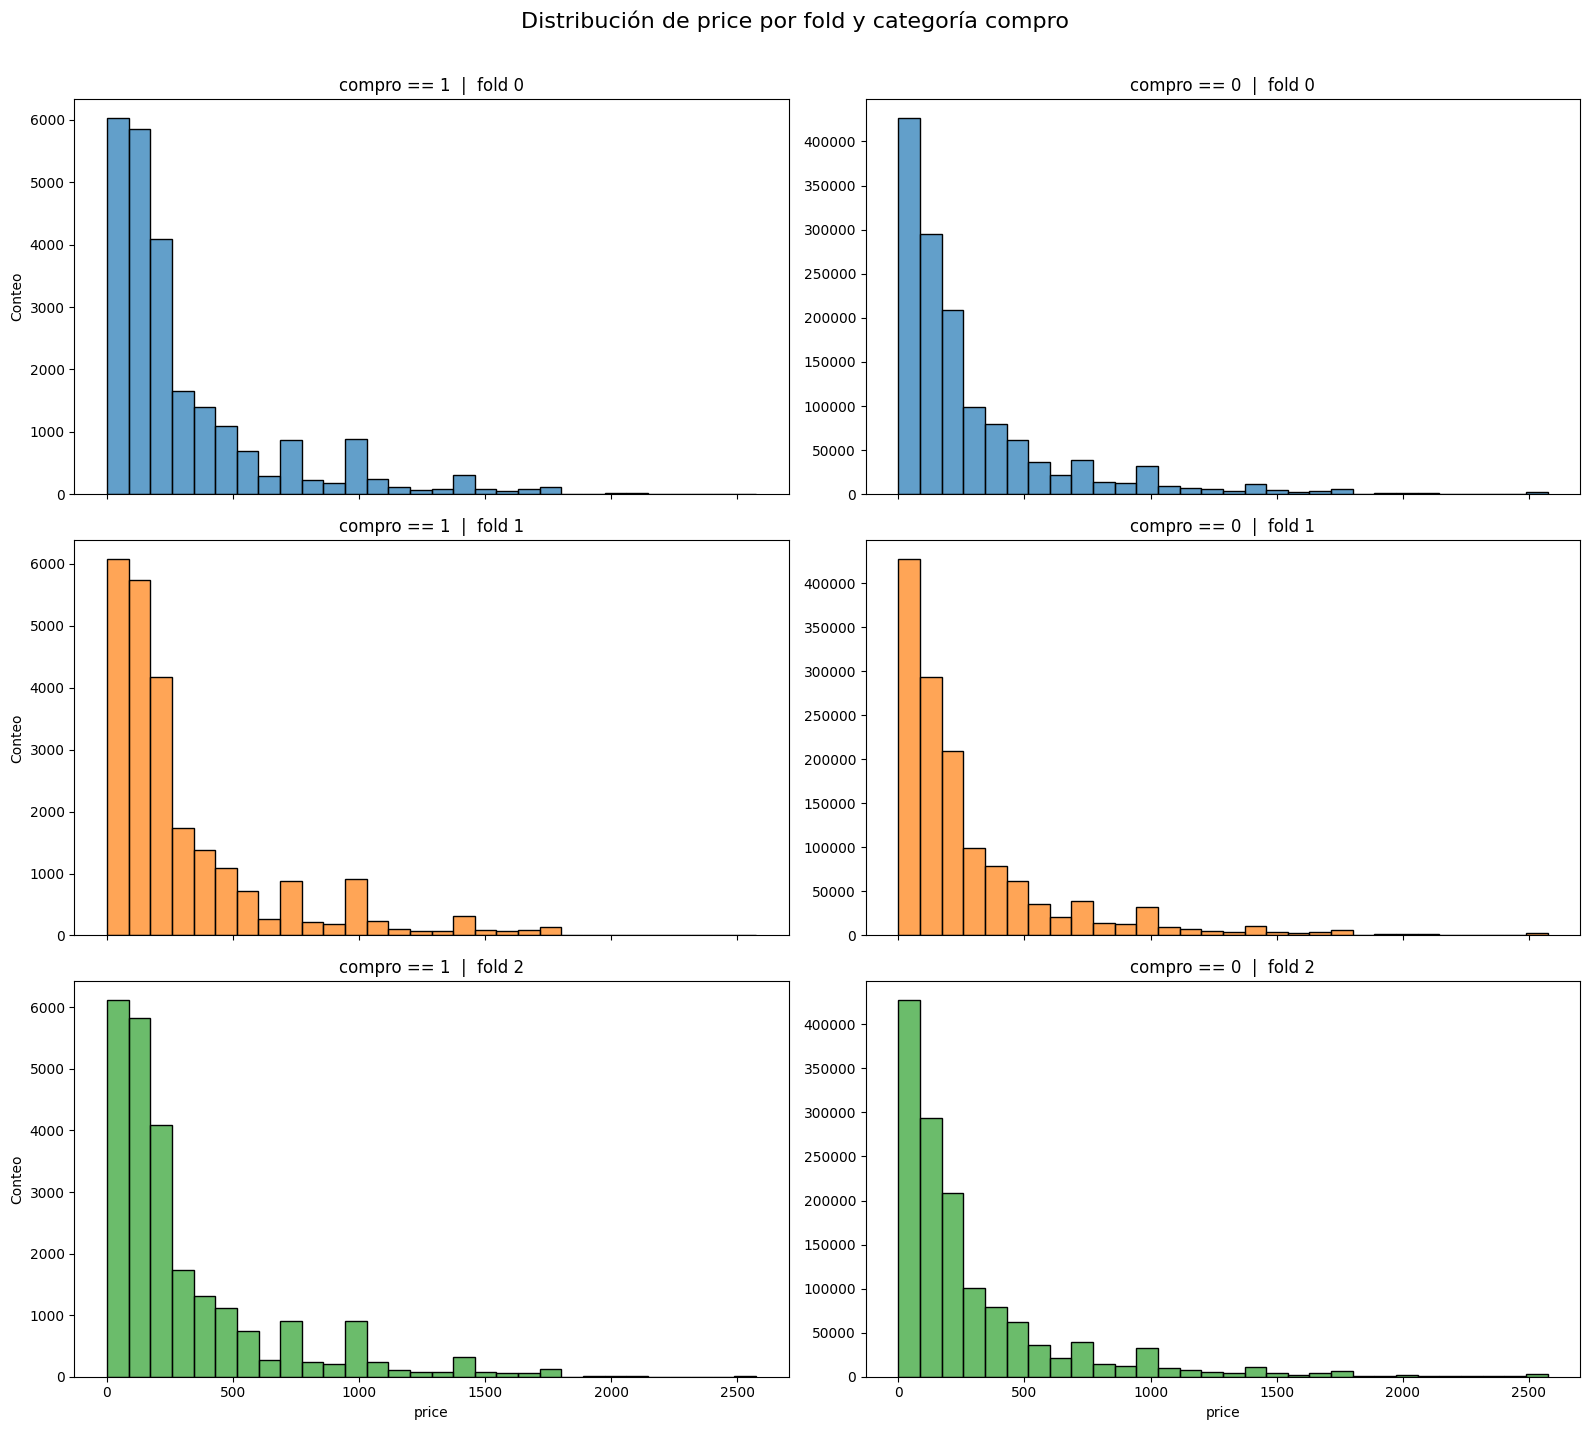

In [ ]:
# ============================================================
# 12. VISUALIZACIÓN: HISTOGRAMAS DE PRICE POR FOLD
# ============================================================

# Histogramas de price por fold, separados por la categoría compro y en un diseño 3x2
pdf_hist = M_folds.select("compro", "price", "fold").toPandas()

fig, axes = plt.subplots(3, 2, figsize=(16, 15), sharex=True, sharey=False)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
folds = sorted(pdf_hist["fold"].unique())

for i, fold in enumerate(folds):
    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    sns.histplot(
        data=pdf_hist[(pdf_hist["compro"] == 1) & (pdf_hist["fold"] == fold)],
        x="price",
        color=colors[i],
        bins=30,
        alpha=0.7,
        edgecolor="black",
        ax=ax_left
    )
    ax_left.set_title(f"compro == 1  |  fold {fold}")
    ax_left.set_xlabel("price")
    ax_left.set_ylabel("Conteo")

    sns.histplot(
        data=pdf_hist[(pdf_hist["compro"] == 0) & (pdf_hist["fold"] == fold)],
        x="price",
        color=colors[i],
        bins=30,
        alpha=0.7,
        edgecolor="black",
        ax=ax_right
    )
    ax_right.set_title(f"compro == 0  |  fold {fold}")
    ax_right.set_xlabel("price")
    ax_right.set_ylabel("")

fig.suptitle("Distribución de price por fold y categoría compro", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

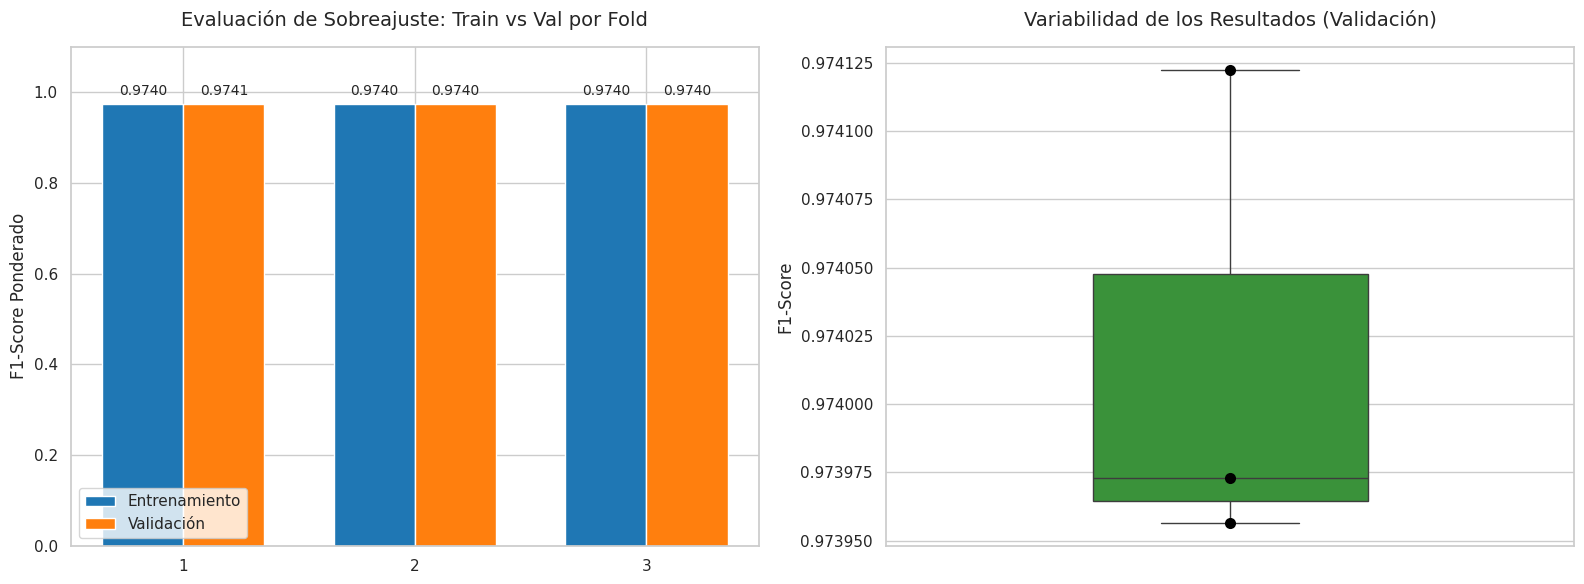


--- ESTADÍSTICAS GENERALES DE VALIDACIÓN CRUZADA ---
F1-Score Promedio (Validación): 0.9740
Desviación Estándar (Variabilidad): 0.0001


In [ ]:
# ============================================================
# 13. VISUALIZACIÓN: TRAIN VS VALIDATION Y BOXPLOT
# ============================================================

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICA 1: Train vs Validation (Overfitting Check) ---
import numpy as np
x = np.arange(len(resultados_pdf['Fold']))
width = 0.35

axes[0].bar(x - width/2, resultados_pdf['F1_Train'], width, label='Entrenamiento', color='#1f77b4')
axes[0].bar(x + width/2, resultados_pdf['F1_Validation'], width, label='Validación', color='#ff7f0e')

axes[0].set_ylabel('F1-Score Ponderado')
axes[0].set_title('Evaluación de Sobreajuste: Train vs Val por Fold', fontsize=14, pad=15)
axes[0].set_xticks(x)
axes[0].set_xticklabels(resultados_pdf['Fold'])
axes[0].legend()
axes[0].set_ylim(0, 1.1)

# Textos sobre las barras
for i, val in enumerate(resultados_pdf['F1_Train']):
    axes[0].text(i - width/2, val + 0.02, f'{val:.4f}', ha='center', fontsize=10)
for i, val in enumerate(resultados_pdf['F1_Validation']):
    axes[0].text(i + width/2, val + 0.02, f'{val:.4f}', ha='center', fontsize=10)

# --- GRÁFICA 2: Boxplot de Variabilidad ---
df_melted = resultados_pdf.melt(id_vars=['Fold'], value_vars=['F1_Validation'], var_name='Métrica', value_name='F1_Score')

sns.boxplot(y='F1_Score', data=df_melted, ax=axes[1], color='#2ca02c', width=0.4)
sns.swarmplot(y='F1_Score', data=df_melted, ax=axes[1], color='black', size=8)

axes[1].set_title('Variabilidad de los Resultados (Validación)', fontsize=14, pad=15)
axes[1].set_ylabel('F1-Score')

plt.tight_layout()
plt.show()

# Imprimir estadísticas descriptivas
print("\n--- ESTADÍSTICAS GENERALES DE VALIDACIÓN CRUZADA ---")
print(f"F1-Score Promedio (Validación): {resultados_pdf['F1_Validation'].mean():.4f}")
print(f"Desviación Estándar (Variabilidad): {resultados_pdf['F1_Validation'].std():.4f}")

## 13. Interpretación de resultados

La interpretación debe considerar tres elementos:

1. **Desempeño promedio:** el F1-score ponderado promedio resume el rendimiento general del modelo en los folds de validación.
2. **Estabilidad:** una baja desviación estándar entre folds sugiere que el modelo no depende excesivamente de una partición específica.
3. **Sobreajuste:** si el F1-score de entrenamiento es mucho mayor que el de validación, existe evidencia de sobreajuste. Si ambos valores son cercanos, el modelo generaliza de forma más estable.

Desde el punto de vista de negocio, el modelo busca identificar señales asociadas a la conversión de compra en eventos de eCommerce. Las variables de precio, categoría, marca agrupada y periodo temporal permiten representar patrones de navegación sin utilizar identificadores de alta cardinalidad como `user_id`, `product_id` o `user_session`.


In [ ]:
# ============================================================
# 14. IMPORTANCIA DE VARIABLES DEL MEJOR MODELO
# ============================================================

# Seleccionar el modelo con mayor F1 de validación
best_idx = int(resultados_pdf["F1_Validation"].idxmax())
best_model = models[best_idx]

# Última etapa del pipeline: DecisionTreeClassificationModel
dt_model = best_model.stages[-1]
print(f"Mejor fold: {best_idx + 1}")
print(f"Profundidad del árbol: {dt_model.depth}")
print(f"Número de nodos: {dt_model.numNodes}")
print("\nImportancias de variables vectorizadas:")
print(dt_model.featureImportances)


Mejor fold: 1
Profundidad del árbol: 0
Número de nodos: 1

Importancias de variables vectorizadas:
(78,[],[])


## 14. Conclusión técnica

El flujo construido permite procesar un dataset masivo de comportamiento de usuarios en eCommerce mediante PySpark, conservando la trazabilidad desde la carga hasta la evaluación del modelo. La muestra representativa se construye con muestreo estratificado proporcional basado en `event_type`, `category_group`, `price_range` y `time_period`, por lo que mantiene la composición de la población original.

La variable objetivo `compro` permite transformar el problema en una tarea de clasificación binaria. El uso de `DecisionTreeClassifier` ofrece un modelo interpretable y eficiente como línea base. La validación cruzada con `k = 3` permite evaluar estabilidad sin imponer un costo computacional excesivo. Finalmente, el F1-score ponderado es la métrica principal porque el dataset está desbalanceado y la clase de compra es minoritaria.

Como trabajo futuro, se recomienda comparar este modelo base contra Random Forest, Gradient-Boosted Trees y modelos con ajuste de hiperparámetros, además de incorporar variables a nivel sesión que representen secuencias de navegación previas a la compra.
